### Nairobi Flood Footprints by Katie, Helen & Ezra

---
## Part 1: Data Acquisition + Preprocessing

We'll pull Sentinel-1 Level-1C Ground Range Detected (GRD) data over Nairobi from May 2024

Sentinel-1 is a pair of Synthetic Aperture Radar (SAR) imaging satellites launched in 2014 and 2016 by the European Space Agency (ESA). Their 6 day revisit cycle and ability to observe through clouds makes this dataset perfect for sea and land monitoring, emergency response due to environmental disasters, and economic applications. This dataset represents the global Sentinel-1 GRD archive, from beginning to the present, converted to cloud-optimized GeoTIFF format.

In [102]:
# Imports
from datetime import datetime, timedelta

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pystac_client
import rioxarray  # noqa: F401
import xarray as xr
from dask.distributed import Client
from matplotlib.patches import Patch
from odc.geo.geobox import GeoBox
from shapely.geometry import Polygon
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

client = Client(processes=False)

In [54]:
# Define spatial and temporal extent
dx = 0.0003  # ~30m resolution
epsg = 4326

# Nairobi area bounds
#-1.5371°, 36.5134° : -1.0918°, 37.2744°
latmin, latmax = -1.5371, -1.0918
lonmin, lonmax = 36.5134, 37.2744
bounds = (lonmin, latmin, lonmax, latmax)

# Temporal extent: May 2026
#start_date = datetime(year=2026, month=3, day=1)
#end_date = start_date + timedelta(days=20)

# Temporal extent: April 2024
start_date = datetime(year=2024, month=2, day=1)
end_date = start_date + timedelta(days=180)

time_format = "%Y-%m-%d"
date_query = f"{start_date.strftime(time_format)}/{end_date.strftime(time_format)}"

# Search for Sentinel-2 data
items = (
    pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
    .search(
        bbox=bounds,
        collections=["sentinel-1-grd"],
        datetime=date_query,
        limit=100,
        query={"sar:instrument_mode": {"in": ["IW"]}},
    )
    .item_collection()
)
print(f"{len(items)} scenes found")


30 scenes found


In [55]:
import os
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'

# Create geobox and load data
geobox = GeoBox.from_bbox(bounds, crs=f"epsg:{epsg}", resolution=dx)

dc = odc.stac.load(
    items,
    bands=["vh"],
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=geobox,
    resampling="bilinear",
)
dc

<xarray.Dataset> Size: 226MB
Dimensions:      (latitude: 1485, longitude: 2537, time: 30)
Coordinates:
  * latitude     (latitude) float64 12kB -1.092 -1.092 -1.092 ... -1.537 -1.537
  * longitude    (longitude) float64 20kB 36.51 36.51 36.51 ... 37.27 37.27
  * time         (time) datetime64[ns] 240B 2024-02-07T15:48:29.415606 ... 20...
    spatial_ref  int32 4B 4326
Data variables:
    vh           (time, latitude, longitude) uint16 226MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>

In [65]:
#2026 Floods
#before =dc.sel(time=slice("2026-03-01", "2026-03-09"))
#after = dc.sel(time=slice("2026-03-10", "2026-03-21")) 
# 2024 floods
before =dc.sel(time=slice("2024-02-01", "2024-04-15"))
after = dc.sel(time=slice("2024-05-20", "2024-07-30")) 

In [71]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
smoothed_before = xr.apply_ufunc(
    gaussian_filter1d,
    before,
    kwargs={'sigma': 2, 'axis': list(before.dims).index('time')},
    dask='parallelized'
)
smoothed_after = xr.apply_ufunc(
    gaussian_filter1d,  
    after,
    kwargs={'sigma': 2, 'axis': list(after.dims).index('time')},
    dask='parallelized'
)

In [72]:
before_mean = smoothed_before.mean(dim="time")
after_mean = smoothed_after.mean(dim="time")

Flood Mask based off the UN-SPIDER Method

In [73]:
#Calculate the difference between the before and after images
difference = after_mean/(before_mean)

In [74]:

#Apply the predefined difference-threshold and create the flood extent mask 
threshold = 1.25;  # This threshold may need to be adjusted based on the data
difference_binary = (difference > threshold).astype(int)

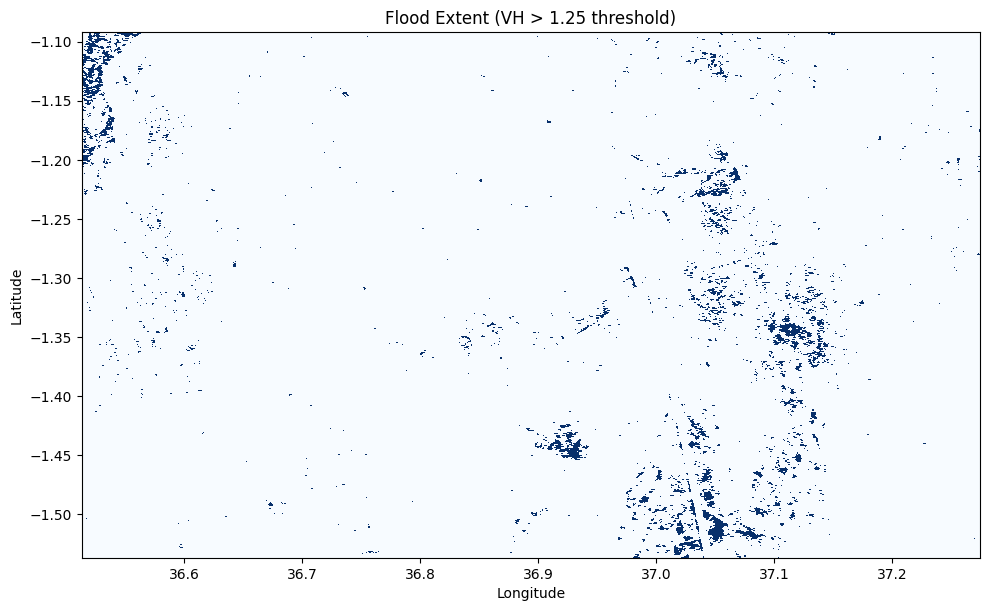

In [75]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    difference_binary.vh.values,
    origin="upper",
    extent=[
        difference_binary.longitude.min().item(),
        difference_binary.longitude.max().item(),
        difference_binary.latitude.min().item(),
        difference_binary.latitude.max().item(),
    ],
    cmap="Blues",
    interpolation="none",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Flood Extent (VH > 1.25 threshold)")
plt.tight_layout()
plt.show()

### Do the same using VV polarization and compare results.

In [ ]:
dc = odc.stac.load(
    items,
    bands=["vv"],
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=geobox,
    resampling="bilinear",
)
dc
#before_vv =dc.sel(time=slice("2026-03-01", "2026-03-09"))
#after_vv = dc.sel(time=slice("2026-03-10", "2026-03-21")) 

before_vv =dc.sel(time=slice("2024-02-01", "2024-04-15"))
after_vv = dc.sel(time=slice("2024-05-20", "2024-07-30")) 


smoothed_before = xr.apply_ufunc(
    gaussian_filter1d,
    before_vv,
    kwargs={'sigma': 2, 'axis': list(before_vv.dims).index('time')},
    dask='parallelized'
)
smoothed_after = xr.apply_ufunc(
    gaussian_filter1d,  
    after_vv,
    kwargs={'sigma': 2, 'axis': list(after_vv.dims).index('time')},
    dask='parallelized'
)   


In [94]:
before_mean = smoothed_before.mean(dim="time").compute()
after_mean = smoothed_after.mean(dim="time").compute()  

#Calculate the difference between the before and after images
difference = after_mean/(before_mean)

#Apply the predefined difference-threshold and create the flood extent mask 
difference_binary_vv = (difference > threshold).astype(int)


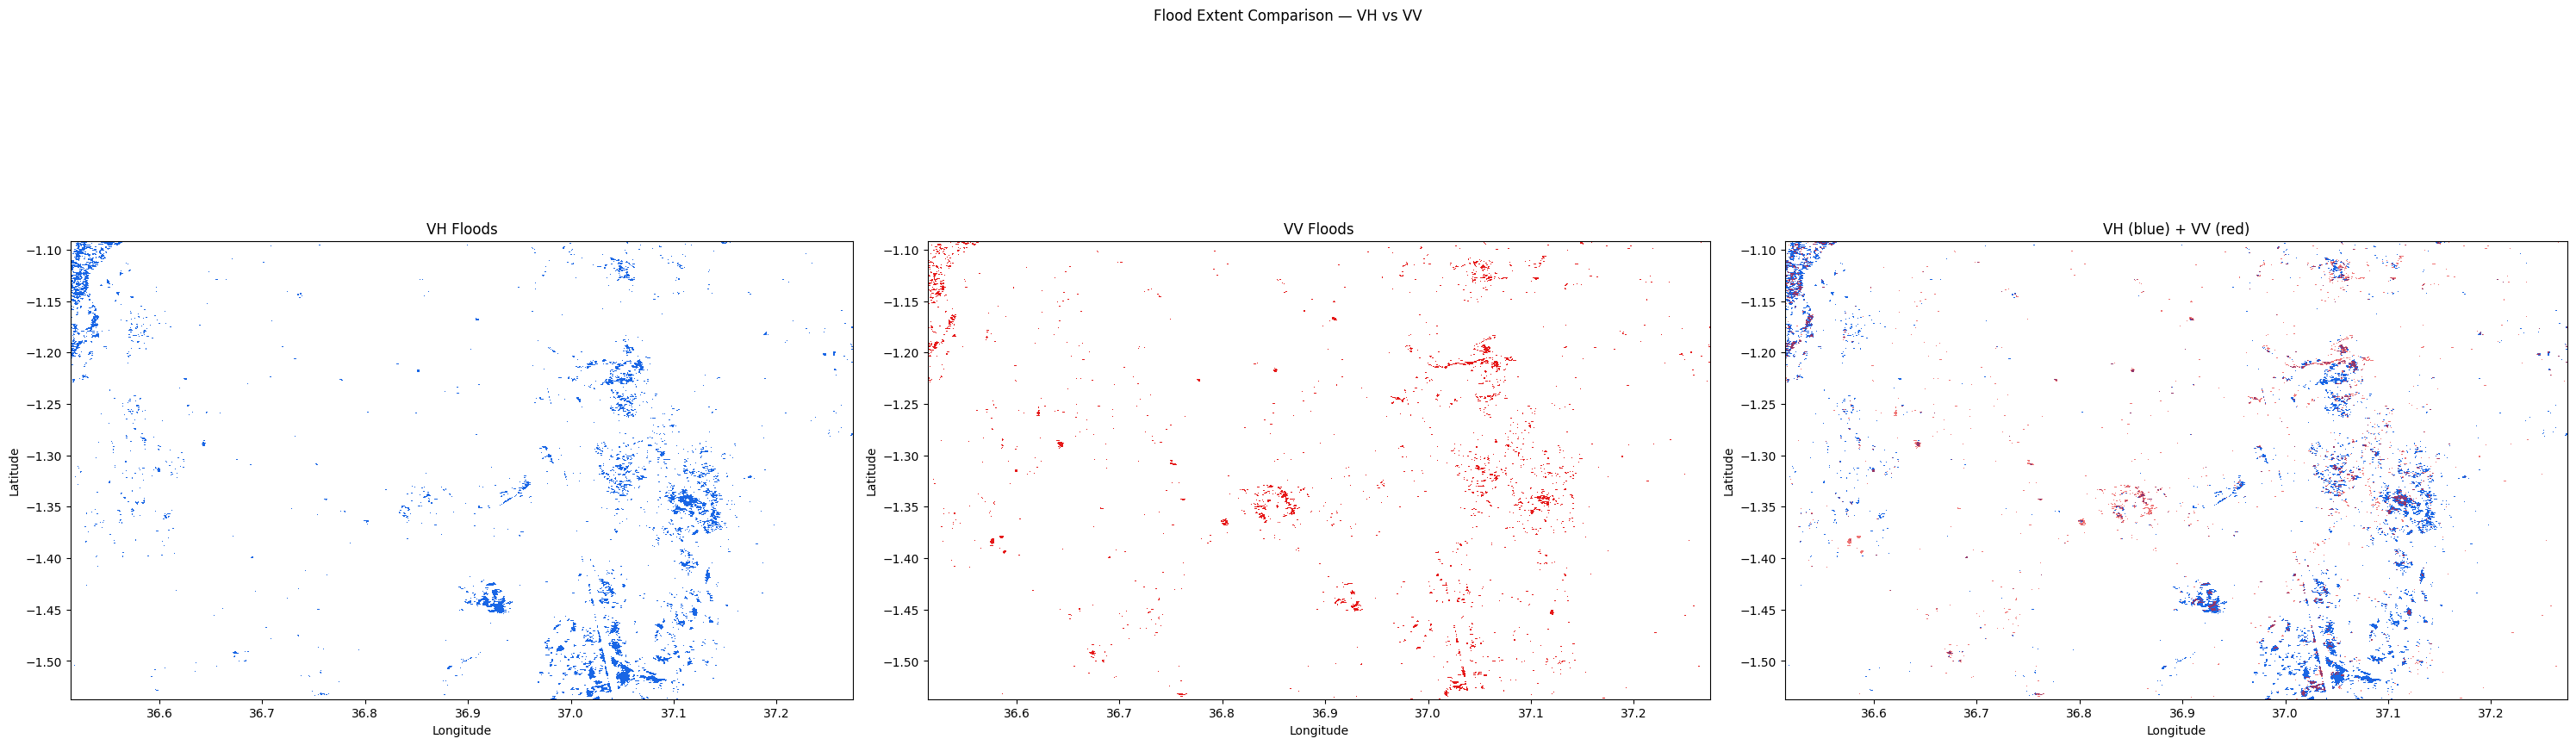

In [95]:
import numpy as np

extent = [
    difference_binary.longitude.min().item(),
    difference_binary.longitude.max().item(),
    difference_binary.latitude.min().item(),
    difference_binary.latitude.max().item(),
]

vh_data = difference_binary.vh.values
vv_data = difference_binary_vv.vv.values

def to_rgba(data, color_rgb):
    """Binary array → RGBA image. Flood pixels get color, zeros are transparent."""
    h, w = data.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    mask = data == 1
    rgba[mask, 0] = color_rgb[0]
    rgba[mask, 1] = color_rgb[1]
    rgba[mask, 2] = color_rgb[2]
    rgba[mask, 3] = 1.0  # fully opaque where flooded
    return rgba

vh_rgba = to_rgba(vh_data, (0.1, 0.4, 0.9))   # blue
vv_rgba = to_rgba(vv_data, (0.9, 0.1, 0.1))   # red

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[0].set_title("VH Floods")

axes[1].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none")
axes[1].set_title("VV Floods")

axes[2].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[2].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none", alpha=0.6)
axes[2].set_title("VH (blue) + VV (red)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Flood Extent Comparison — VH vs VV", y=1.02)
plt.tight_layout()
plt.show()

In [96]:
# This is the ground truth data from Google Research for the floods across the globe from media reports. 
# It contains polygons of flooded areas with their start and end dates, as well as their area in km2.
# We will use this data to evaluate our flood extent maps derived from Sentinel-1. SAR data 
groundtruth = gpd.read_parquet("C:/Users/Ez/OneDrive/Work/Penn/Courses/DeepLearning/groundsource_2026.parquet")

In [97]:
import pandas as pd
groundtruth["start_date"] = pd.to_datetime(groundtruth["start_date"])
groundtruth["end_date"]   = pd.to_datetime(groundtruth["end_date"])

groundtruth = groundtruth[
    (groundtruth["area_km2"] > 5) &
    (groundtruth["area_km2"] <= 600)
    & (groundtruth["start_date"].dt.year == 2024)
].copy()

print(groundtruth.shape)


(133371, 5)


In [98]:
from shapely.geometry import box

nairobi_box = box(lonmin, latmin, lonmax, latmax)

groundtruth = groundtruth[groundtruth.geometry.intersects(nairobi_box)].copy()

print(groundtruth.shape)


(125, 5)


<Axes: xlabel='start_date'>

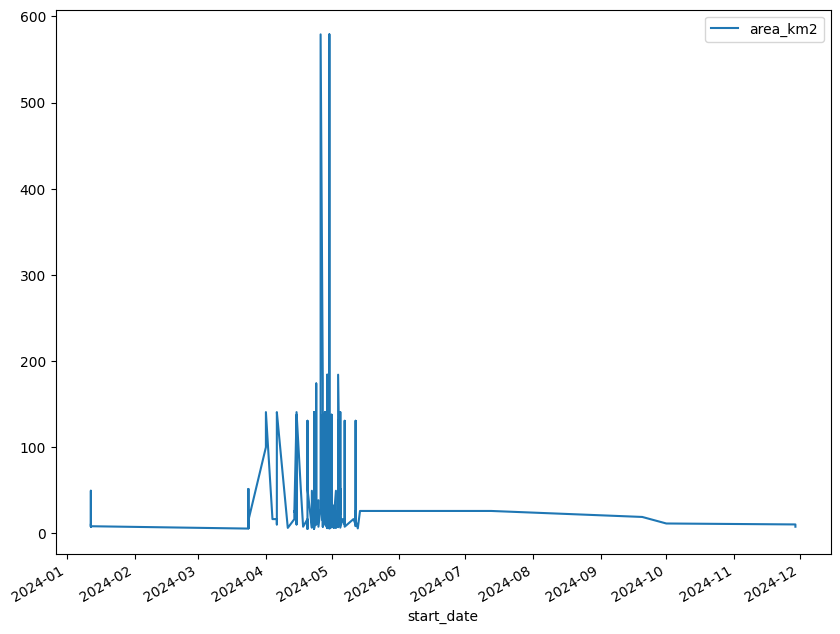

In [99]:
groundtruth.plot(kind="line", x="start_date", y="area_km2", figsize=(10, 8))

In [100]:
groundtruth.explore(column="area_km2", cmap="viridis", figsize=(10, 8))

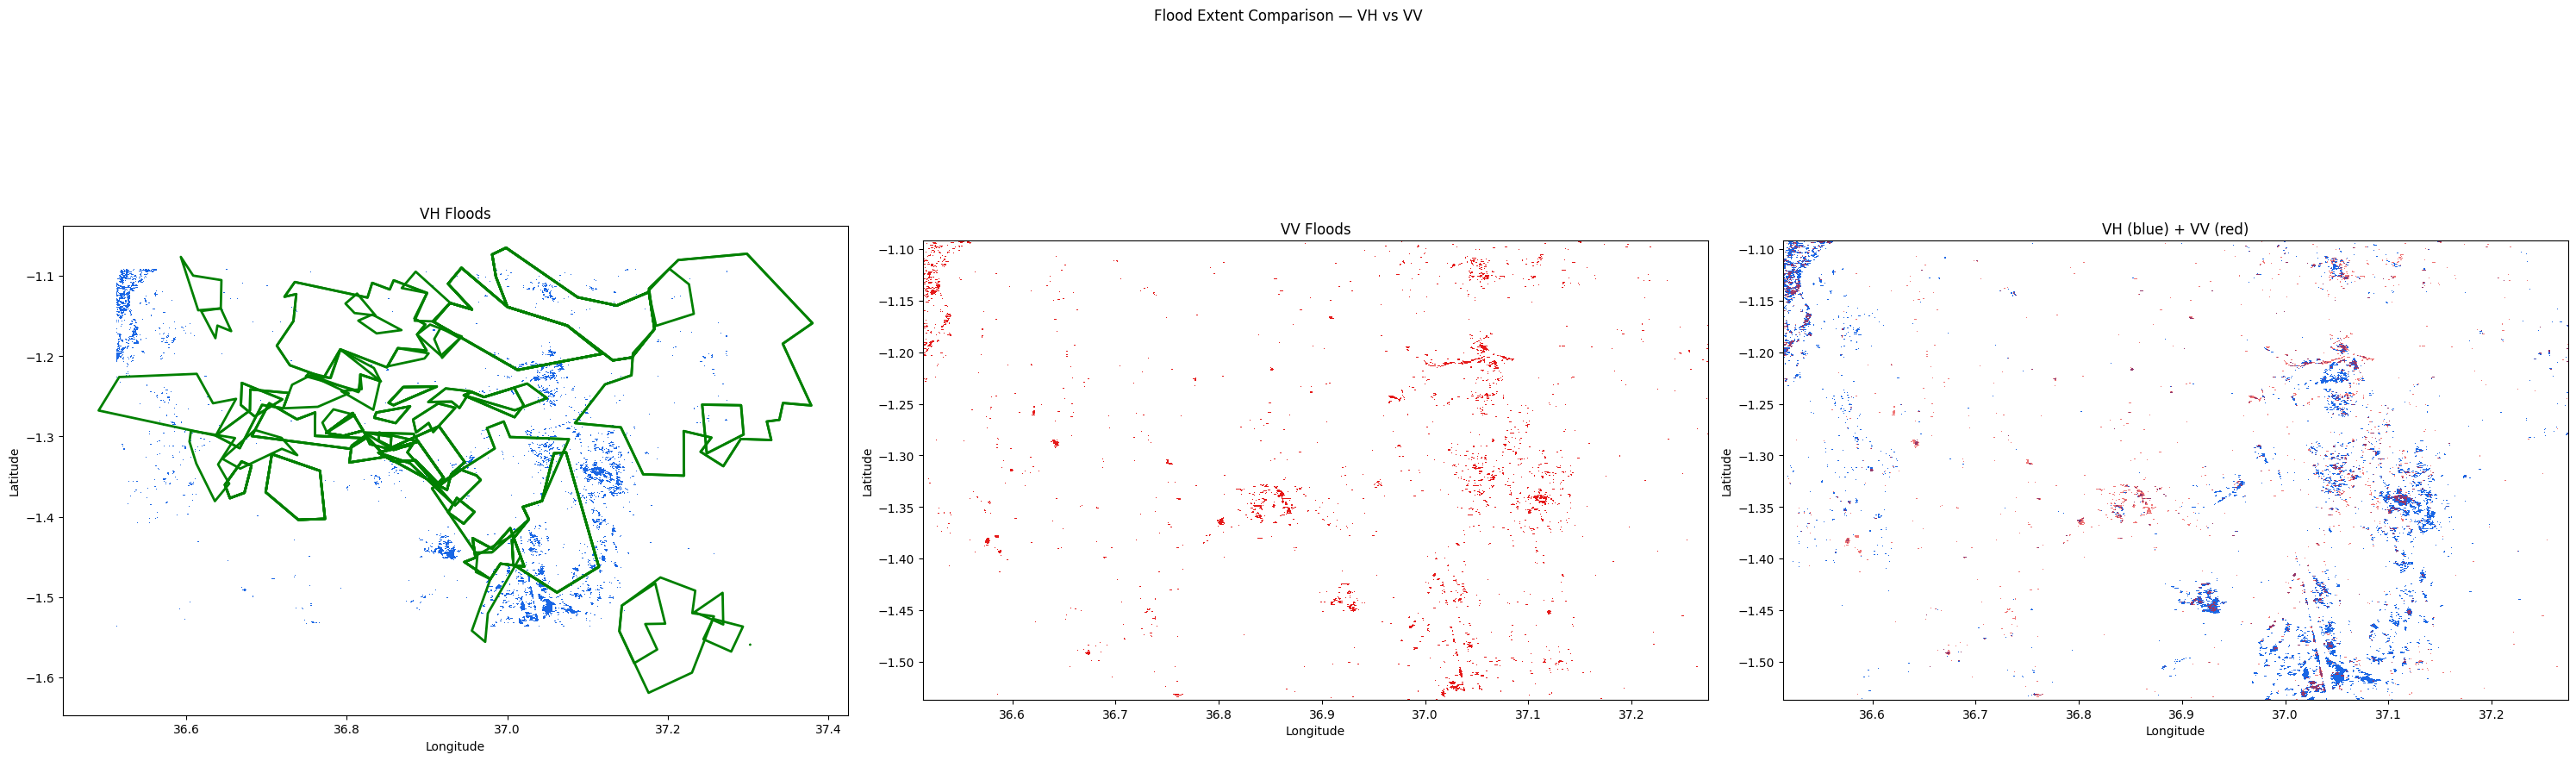

In [101]:
extent = [
    difference_binary.longitude.min().item(),
    difference_binary.longitude.max().item(),
    difference_binary.latitude.min().item(),
    difference_binary.latitude.max().item(),
]

vh_data = difference_binary.vh.values
vv_data = difference_binary_vv.vv.values

def to_rgba(data, color_rgb):
    """Binary array → RGBA image. Flood pixels get color, zeros are transparent."""
    h, w = data.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    mask = data == 1
    rgba[mask, 0] = color_rgb[0]
    rgba[mask, 1] = color_rgb[1]
    rgba[mask, 2] = color_rgb[2]
    rgba[mask, 3] = 1.0  # fully opaque where flooded
    return rgba

vh_rgba = to_rgba(vh_data, (0.1, 0.4, 0.9))   # blue
vv_rgba = to_rgba(vv_data, (0.9, 0.1, 0.1))   # red

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[0].set_title("VH Floods")
groundtruth.plot(
    ax=axes[0], facecolor="none", edgecolor="green", linewidth=2, label="Forest"
)

axes[1].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none")
axes[1].set_title("VV Floods")

axes[2].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[2].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none", alpha=0.6)
axes[2].set_title("VH (blue) + VV (red)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Flood Extent Comparison — VH vs VV", y=1.02)
plt.tight_layout()
plt.show()

### Using Sentinel 1 Multi-Spectral Bands - Adding Deep Learning Approach

Few paper examples:
<br>
<br>
https://www.sciencedirect.com/science/article/pii/S2666017225000094#sec3
<br>
<br>
Perhaps this paper that uses voting - https://www.nature.com/articles/s41598-026-41014-3    